In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("LMS_2013-01-01_2026-03-24_HALF_HOUR_au.csv")
weather = pd.read_excel("weather_2025-10-06_2026-03-01_15min.xlsx")
NMI = pd.read_excel("LMS Serial to NMI Map.xlsx")
building = pd.read_excel("Archibus Extract_Buildings_Jan 2025.xlsx")
BN = pd.read_excel("building_no_to_site_id.xlsx")

In [4]:
df["date"] = pd.to_datetime(df["date"])

In [5]:
df.shape

(231840, 102)

In [6]:
df.dtypes

date                      datetime64[ns]
6102000812 consumption           float64
6102002302 consumption           float64
6102005454 consumption           float64
6102005592 consumption           float64
                               ...      
VAAA004066 consumption           float64
VCCCAE0035 consumption           float64
VCCCBC0096 consumption           float64
VCCCSC0045 consumption           float64
VCCCSD0058 consumption           float64
Length: 102, dtype: object

In [7]:
# Two meters rolled out of UniMelb
df = df.drop(columns=["6102507141 consumption","VAAA003225 consumption"])

In [8]:
# Getting meter list
meters = list(df.columns)

In [9]:
# Checking if every day has 48 rows
counts = df.groupby(df["date"].dt.date).size().reset_index(name="count")
counts.loc[counts["count"] != 48,["date"]]

,date


In [10]:
df = df.set_index("date")

In [11]:
df['site_total'] = df.sum(axis=1)

In [12]:
df_yearly = df.resample("YE").sum()
df_monthly = df.resample("ME").sum()
df_daily = df.resample("D").sum()
df_hourly = df.resample("h").sum()

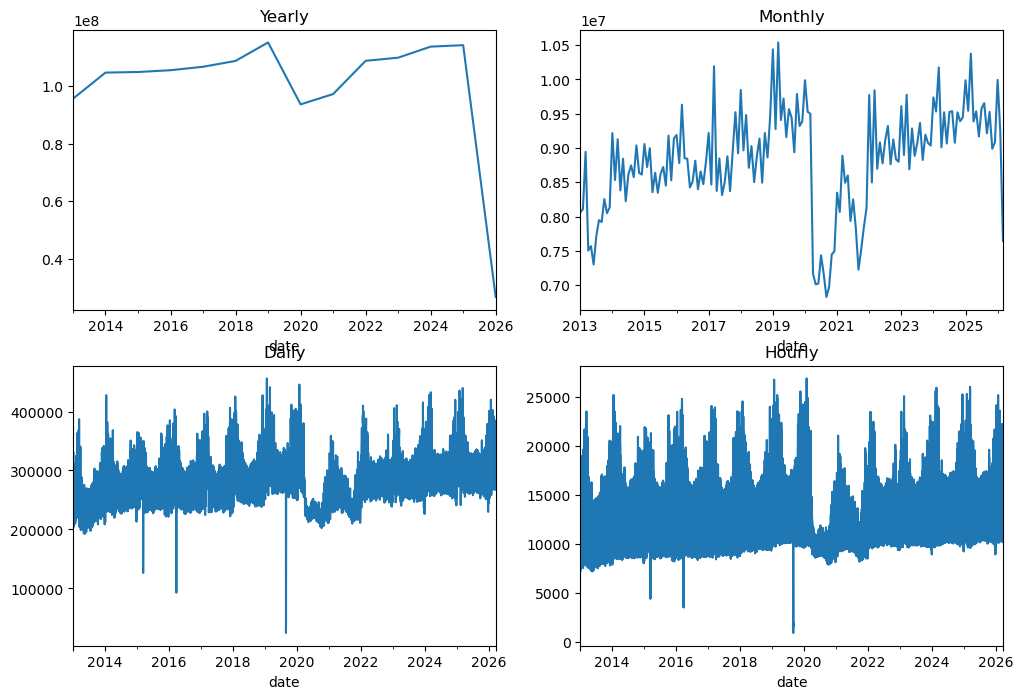

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12,8))

df_yearly['site_total'].plot(ax=axes[0,0], title="Yearly")
df_monthly['site_total'].plot(ax=axes[0,1], title="Monthly")
df_daily['site_total'].plot(ax=axes[1,0], title="Daily")
df_hourly['site_total'].plot(ax=axes[1,1], title="Hourly")

plt.show()

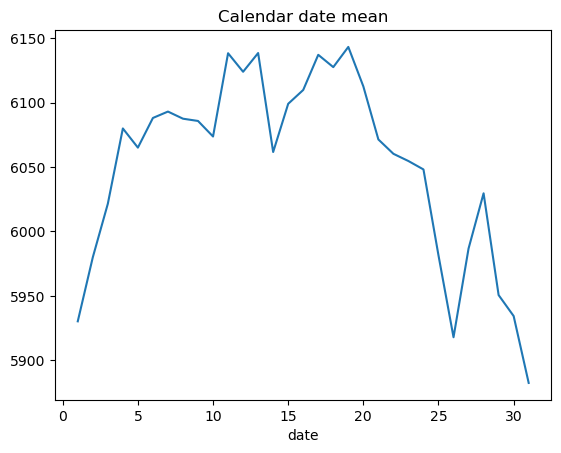

In [14]:
date = df.groupby(df.index.day)['site_total'].mean()
date.plot()
plt.title('Calendar date mean')
plt.show()

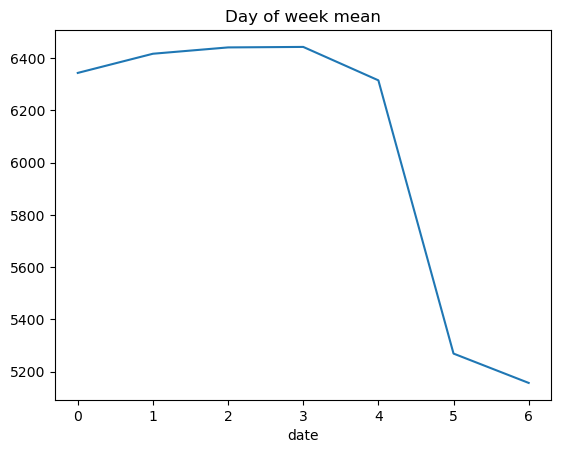

In [15]:
week = df.groupby(df.index.dayofweek)['site_total'].mean()
week.plot()
plt.title('Day of week mean')
plt.show()

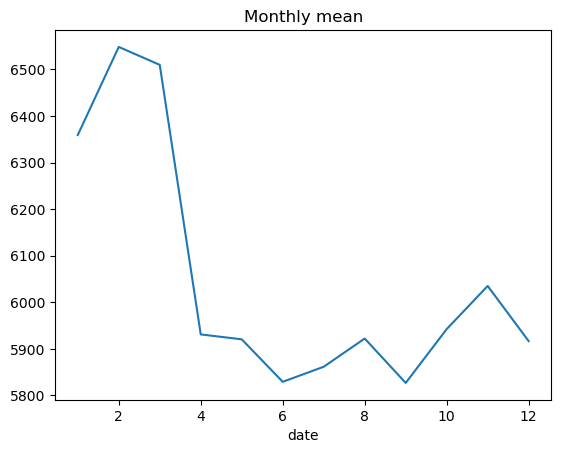

In [16]:
month = df.groupby(df.index.month)['site_total'].mean()
month.plot()
plt.title('Monthly mean')
plt.show()

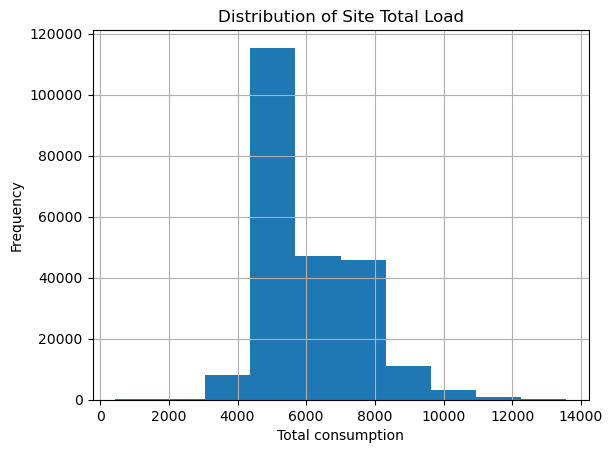

In [17]:
df['site_total'].hist()
plt.xlabel('Total consumption')
plt.ylabel('Frequency')
plt.title('Distribution of Site Total Load')



plt.show()

<Axes: >

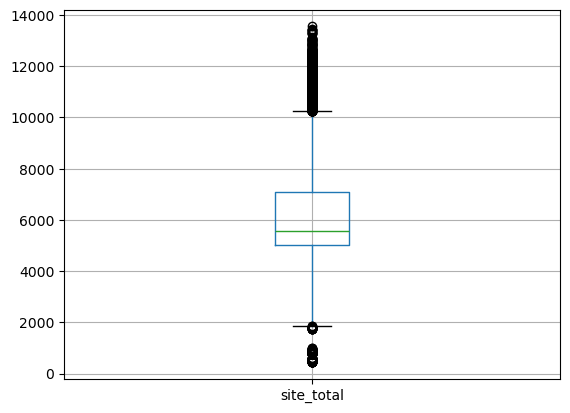

In [18]:
df.boxplot(column=['site_total'])

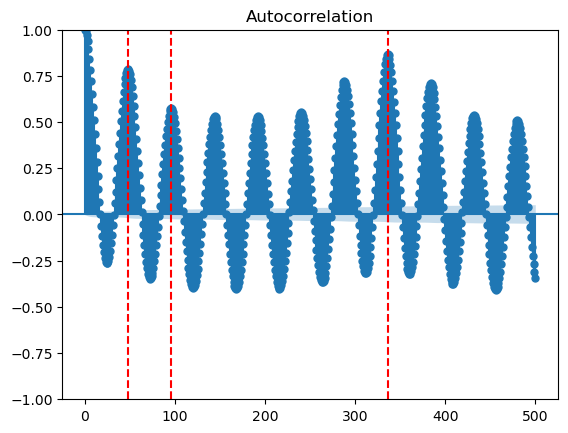

In [19]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['site_total'], lags=500)
for lag in [48, 96, 336]:
    plt.axvline(x=lag, color='red', linestyle='--')
plt.show()

In [20]:
season_dict = {
    1: 'Summer',
    2: 'Summer',
    3: 'Autumn',
    4: 'Autumn',
    5: 'Autumn',
    6: 'Winter',
    7: 'Winter',
    8: 'Winter',
    9: 'Spring',
    10: 'Spring',
    11: 'Spring',
    12: 'Summer'
}

df['season'] = df.index.month.map(season_dict)

In [21]:
weather["observationendtime"] = pd.to_datetime(weather["observationendtime"].str.split('.').str[0])

In [22]:
temp = weather.loc[weather['observationtag'] == 'AIR_TEMPERATURE']

In [23]:
temp = temp.loc[temp['locationcode'] == 'PAR']

In [24]:
temp = temp.set_index('observationendtime')

In [ ]:
max_temp = pd.read_excel("Mean Max.xlsx")
min_temp = pd.read_excel("Mean Min.xlsx")
rainfall = pd.read_excel("Rainfall.xlsx")
solar = pd.read_excel("Solar.xlsx")

In [ ]:
df.boxplot(column=['site_total'],by=['season'])

In [28]:
df.describe()

,6102000812 consumption,6102002302 consumption,6102005454 consumption,6102005592 consumption,6102009742 consumption,6102009743 consumption,6102009744 consumption,6102023971 consumption,6102038376 consumption,6102046251 consumption,...,VAAA003176 consumption,VAAA003194 consumption,VAAA003197 consumption,VAAA003429 consumption,VAAA004066 consumption,VCCCAE0035 consumption,VCCCBC0096 consumption,VCCCSC0045 consumption,VCCCSD0058 consumption,site_total
count,231840.000000,231840.000000,231840.000000,231840.000000,231840.000000,231840.000000,231840.000000,231840.000000,231840.000000,231840.000000,...,231840.000000,231840.000000,231840.000000,231840.000000,231840.000000,231840.000000,231840.000000,231840.000000,231840.000000,231840.000000
mean,27.465821,18.859537,66.030273,53.571213,6.675273,56.928182,48.123391,369.877367,79.634271,36.242795,...,36.663603,40.192117,78.478749,2.781338,0.031602,122.177376,27.536321,26.705448,30.516319,6055.155168
std,9.893390,15.006186,18.446442,49.795488,1.616956,40.853639,38.728486,74.172961,23.667923,22.964537,...,22.487764,18.824304,44.710427,4.270257,0.130159,32.398042,9.774388,16.944389,16.818661,1411.533976
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,436.270000
25%,19.776000,10.120000,52.800000,12.620000,5.488000,25.928000,18.540000,311.100000,64.080000,17.680000,...,19.860000,27.799000,42.340000,0.000000,0.000000,108.032000,22.020000,13.830000,21.024000,5007.990500
50%,25.536000,12.120000,61.600000,41.792000,6.384000,32.684000,24.660000,365.520000,76.799000,29.040000,...,24.780000,34.040000,66.960000,1.600000,0.000000,124.032000,27.000000,23.167000,28.768000,5575.480500
75%,32.768000,23.400000,76.000000,74.400000,7.648000,96.366000,85.320000,417.239000,92.220000,53.160000,...,56.640000,50.540000,110.400000,2.656000,0.000000,137.120000,33.180000,37.160000,39.103000,7106.051750
max,90.816000,113.759000,145.700000,372.240000,16.672000,258.011000,242.460000,681.800000,258.599000,156.880000,...,135.300000,205.000000,265.380000,25.024000,14.192000,322.208000,89.205000,118.336000,123.936000,13559.546000


In [29]:
df[['6103086897 consumption']]

,6103086897 consumption
date,
2013-01-01 00:00:00,0.0
2013-01-01 00:30:00,0.0
2013-01-01 01:00:00,0.0
2013-01-01 01:30:00,0.0
2013-01-01 02:00:00,0.0
...,...
2026-03-23 21:30:00,0.0
2026-03-23 22:00:00,0.0
2026-03-23 22:30:00,0.0
